In [1]:
import os
import math
from utils import *

import pennylane as qml
from pennylane import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 42

# Generating the dataset

We will generate a synthetic dataset, generated by solving the Lorentz system using the Euler method. The Lorenz equations are defined as:

$$
\dot{x} = \sigma (y-x)
$$
$$
\dot{y} = -y -zx + \rho x
$$
$$
\dot{z} = -\beta z +xy
$$

where $(x, y, z)$ are the variables and $(\sigma , \rho , \beta)$ are parameters. 

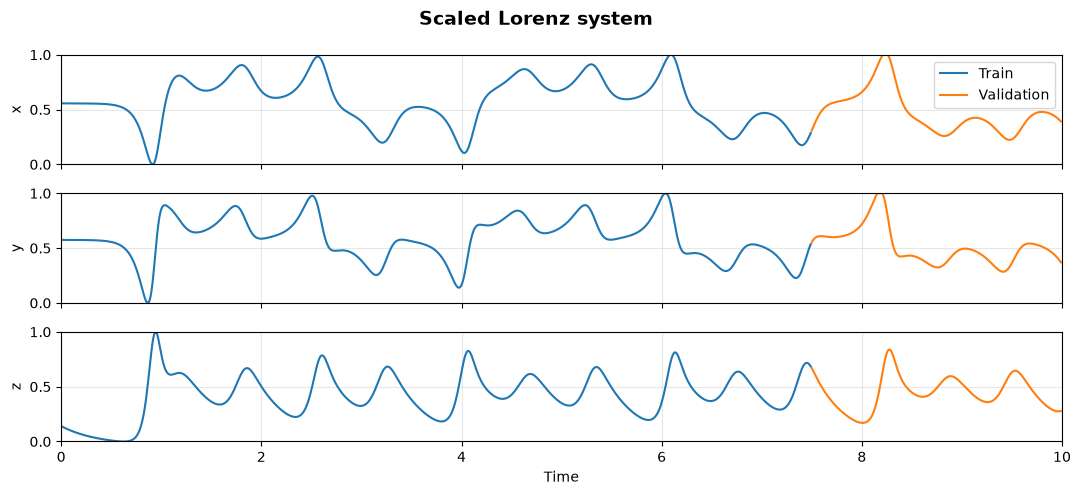

In [2]:
npoints = 1000
h = 0.01
params = [10, 28, 8 / 3]
init_point = [0, -0.01, 9]

dataset = generate_lorenz(
    npoints, 
    h,
    params, 
    init_point
)

# Trin test split
dataset_train, dataset_val = train_test_split(
    dataset,
    test_size=0.25,
    shuffle=False
)
time = np.arange(npoints) * h

time_tr = time[:len(dataset_train)]
time_val = time[len(dataset_train):]

# Scale the data to the range [0, 1]
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(dataset_train)
val_scaled = scaler.transform(dataset_val)
val_scaled = np.clip(val_scaled, 0, 1)

plot_lorenz(train_scaled, val_scaled, time_tr, time_val)

# iTransformer

The iTransformer encondes each variable as a token $X_{:,c}\in \mathbb{R}^T$, transposing the tokenization mechanism of the stardard Transformer. This architecture replaces traditional positional encodings by modeling temporal patterns through shared, token-independent feed-forward networks, while using an attention mechanism to capture inter-variable dependencies. This yields a more intuitive representation of multivariate time series data. The forecasting pipeline is given by:

$$
X'_{:,c}=LN(X_{:,c})
$$

$$
h_c^0 = \phi_{token}(X'_{:,c})
$$

$$
H^{l+1} = \text{TrmBlock}(H^l), \quad l = 0,..., L-1
$$

$$
Y'_{:,c} = \phi_{proj}(h_c^L)
$$

$$
\hat{Y}_{:,c} = LN^{-1}(Y'_{:,c})
$$

where $H^l = [h_1^l;...;h_C^l]\in \mathbb{R}^{C\times D}$ is the matrix of $C$ variate tokens at layer $l$, and $\phi_{token}:\mathbb{R}^T \rightarrow \mathbb{R}^D$ and $\phi_{proj}:\mathbb{R}^D \rightarrow \mathbb{R}^S$ are single layer linear mappings acting along the temporal dimension, with $D$ the token dimension. $LN$ denotes layer normalization that is applied independently to each variate token:

$$
LN(h_c) = \frac{h_c-\mu (h_c)}{\sqrt{\sigma^2 (h_c) + \epsilon}}, \quad c=1,...,C
$$

where $\mu(h_c)$ and $\sigma^2(h_c)$ denote the mean and variance of the $T$-dimensional features and $LN^{-1}(\cdot)$ denotes the denormalization operator.

Each Transformer block combines single-head self-attention across variates with a position-wise feed-forward network. With residual conections and post-normalization, the update is:

$$
\tilde{H}^l = H^l + \text{SelfAttn}(\text{LN}'(H^l))
$$
$$
\tilde{H}^{l+1} = \tilde{H}^l  + \text{FFN}(\text{LN}'(\tilde{H}^l))
$$

where $LN'(\cdot)$ referts to the same standard layer normalization introduced before, with the difference that it operates along the channel dimension $C$.

Within the self-attention layer, the queries keys and values are obtained via linear projections:

$$
Q = H^lW_Q, \quad K = H^lW_K, \quad V = H^lW_V
$$

with $W_Q, W_K, W_V \in \mathbb{R}^{D\times d_k}$, where $d_k = D/M$ denotes the projected dimension. Since iTransformer employs a single-head attention mechanism, then $M=1$ and $d_k=D$. The attention weights are computed as:

$$
A = \text{Softmax}\left (\frac{QK^T}{\sqrt{d_k}} \right ) \in \mathbb{R}^{C\times C}
$$

and the attention output is:

$$
\text{SelfAttn}(H^l) = AV \in \mathbb{R}^{C \times d_k}
$$

The feed-forward network acts independently on each variate token and its given by:

$$
FFN(h) = W_2 ReLU(W_1h+b_1)+b_2, \quad h\in\mathbb{R}^D
$$

The first affine layer expands the token from $\mathbb{R}^D$ to $\mathbb{R}^{D_{ff}}$, where $D_{ff}$ is the internal dimension of the $FFN$, and the second layer projects it back to $\mathbb{R}^D$.

Given all of this, the iTransformer can capture multivariate relationships and is well suited for our forecasting problem.

In [3]:
# Params
batch_size = 128 
n_chanels = 3
window_size = 5
batch_size = 128
n_trfm_blocks = 2 
embding_dim = 9
ff_dim = 12

# Training hyperparameters
epochs = 50
lr = 5e-4

In [4]:
class ClassicalSelfAttention(nn.Module):
    def __init__(self,
                embding_dim
        ):
        super().__init__()
        self.dk = embding_dim 

        self.Wq = nn.Linear(embding_dim, self.dk)
        self.Wk = nn.Linear(embding_dim, self.dk)
        self.Wv = nn.Linear(embding_dim, self.dk)


    def forward(self, x):
        # x: (B, C, D)
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        # (B, C, D) @ (B, D, C) -> (B, C, C)
        attention_weights = Q @ K.transpose(1, 2) / math.sqrt(self.dk)

        # SoftMax in last dim (keys)
        attention_weights = torch.softmax(attention_weights, dim=-1)

        # (B, C, C) @ (B, C, D) -> (B, C, D)
        output = attention_weights @ V

        return output


class TransformerBlock(nn.Module):
    def __init__(self,
                embding_dim,
                ff_dim,
                eps=1e-5
        ):
        super().__init__()

        self.eps = eps

        self.self_att = ClassicalSelfAttention(embding_dim)

        self.feedforward = nn.Sequential(
            nn.Linear(embding_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embding_dim)
        )

    def normalize(self, x):
        # x: (B, C, D)
        mean = x.mean(dim=1, keepdim=True)
        var = x.var(dim=1, keepdim=True, unbiased=False)
        std = torch.sqrt(var + self.eps)

        x_normalized = (x - mean) / std

        return x_normalized

    def forward(self, x):
        x = x + self.self_att(self.normalize(x))
        x = x + self.feedforward(self.normalize(x))
        return x


class iTransformer_Model(nn.Module):
    def __init__(self, 
                window_size, 
                horizon, 
                n_trfm_blocks,
                embding_dim,
                ff_dim,
                eps=1e-5
        ):
        super().__init__()

        self.eps = eps

        self.token_embedding = nn.Linear(
            window_size, 
            embding_dim
        )

        self.trfm_blocks = nn.ModuleList([
            TransformerBlock(embding_dim, ff_dim)
            for _ in range(n_trfm_blocks)
        ])

        self.output_projection = nn.Linear(
            embding_dim, 
            horizon
        )

    def normalize(self, x):
        mean = x.mean(dim=2, keepdim=True)
        var = x.var(dim=2, keepdim=True, unbiased=False)
        std = torch.sqrt(var + self.eps)

        x_normalized = (x - mean) / std

        return x_normalized, mean, std

    def denormalize(self, x, mean, std):
        return x * std + mean
    

    def forward(self, x):
        # x.shape = (batch, window_size, chanels)

        x = x.transpose(1, 2) # (batch, chanels, window_size)

        x, mean, std = self.normalize(x)

        x = self.token_embedding(x) # (batch, chanels, embding_dim) 

        for block in self.trfm_blocks:
            x = block(x)

        x = self.output_projection(x) # (batch, chanels, horizon) 

        x = self.denormalize(x, mean, std)

        x = x.transpose(1, 2) # (batch, horizon, chanels) 

        return x

# Short-term forecasting

In [5]:
# Create the sequences
horizon_short = 1

x_tr_short, hor_tr_short = create_sequences(train_scaled, window_size, horizon_short)
x_val_short, hor_val_short = create_sequences(val_scaled, window_size, horizon_short)

x_tr_short = torch.from_numpy(x_tr_short).double()
hor_tr_short = torch.from_numpy(hor_tr_short).double()

x_val_short = torch.from_numpy(x_val_short).double()
hor_val_short = torch.from_numpy(hor_val_short).double()

tr_dataset_short = TensorDataset(x_tr_short, hor_tr_short)
tr_loader_short = DataLoader(tr_dataset_short, batch_size=batch_size, shuffle=False)

In [6]:
reset_seeds(SEED)

# Create the model
model_iTransformer_short = iTransformer_Model(
    window_size, 
    horizon_short, 
    n_trfm_blocks,
    embding_dim,
    ff_dim,
).double()

# Define optimizer and loss function
opt_short = torch.optim.Adam(params=model_iTransformer_short.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# Save the best model
best_state_short = None
best_val_loss_short = float("inf")

history_short = {"Loss": [], "Val loss": []}

print(30 * "#")
print("Starting training")
print(30 * "#")

for epoch in range(epochs):

    #Training
    model_iTransformer_short.train()
    epoch_loss = 0
    for xb, yb in tr_loader_short:
        opt_short.zero_grad()
        pred = model_iTransformer_short(xb)
        pred = pred.reshape(pred.shape[0], -1)
        target = yb.reshape(yb.shape[0], -1)
        loss = loss_fn(pred, target)    
        loss.backward()
        opt_short.step()
        epoch_loss += loss.item()
    
    # Store average loss for this epoch
    epoch_loss /= len(tr_loader_short)
    history_short["Loss"].append(epoch_loss)

    # Evaluation
    model_iTransformer_short.eval()
    with torch.no_grad():
        val_pred = model_iTransformer_short(x_val_short)
        val_pred = val_pred.reshape(val_pred.shape[0], -1)
        val_target = hor_val_short.reshape(hor_val_short.shape[0], -1)
        val_loss = loss_fn(val_pred, val_target).item()

    # Store val loss
    history_short["Val loss"].append(val_loss)

    # Save best model
    if val_loss < best_val_loss_short:
        best_val_loss_short = val_loss
        best_state_short = {
            name: params.detach().clone()
            for name, params in model_iTransformer_short.state_dict().items()
        }

    # Print training progress every 5 epochs
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


if best_state_short is not None:
    model_iTransformer_short.load_state_dict(best_state_short)

##############################
Starting training
##############################
Epoch: 1 | Loss: 0.0026 | Validation loss: 0.0017
Epoch: 5 | Loss: 0.0020 | Validation loss: 0.0014
Epoch: 10 | Loss: 0.0013 | Validation loss: 0.0010
Epoch: 15 | Loss: 0.0009 | Validation loss: 0.0008
Epoch: 20 | Loss: 0.0007 | Validation loss: 0.0007
Epoch: 25 | Loss: 0.0006 | Validation loss: 0.0007
Epoch: 30 | Loss: 0.0006 | Validation loss: 0.0006
Epoch: 35 | Loss: 0.0005 | Validation loss: 0.0005
Epoch: 40 | Loss: 0.0005 | Validation loss: 0.0005
Epoch: 45 | Loss: 0.0004 | Validation loss: 0.0005
Epoch: 50 | Loss: 0.0004 | Validation loss: 0.0005


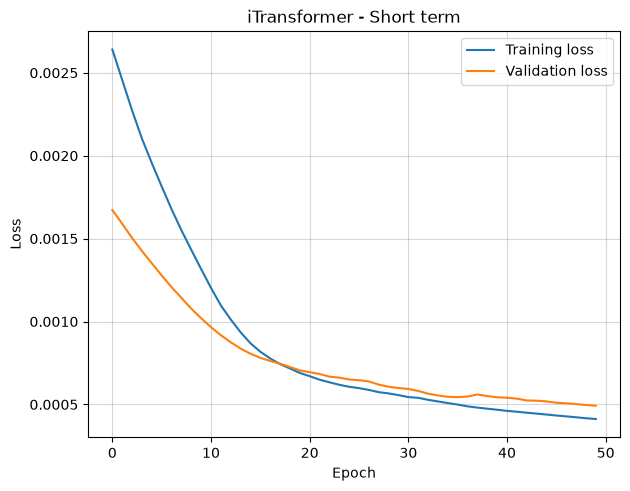

In [7]:
plot_loss(history_short, "iTransformer - Short term")

In [8]:
# Evaluation mode
model_iTransformer_short.eval()

with torch.no_grad():
    pred_short = model_iTransformer_short(x_val_short)

pred_3d_short = pred_short.reshape(pred_short.shape[0], 1, 3)
target_3d_short = hor_val_short

# =====================
# RMSE
# =====================

squared_error_short = (pred_3d_short - target_3d_short) ** 2
mean_rmse_list_short = torch.sqrt(squared_error_short.mean(dim=(1, 2)))
mean_rmse_short = torch.sqrt(squared_error_short.mean())

# =====================
# MAE
# =====================

abs_error_short = torch.abs(pred_3d_short - target_3d_short)
mean_mae_list_short = abs_error_short.mean(dim=(1, 2))
mean_mae_short = abs_error_short.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error_short = torch.abs((target_3d_short - pred_3d_short) / (target_3d_short + eps))
mean_mape_list_short = percentage_error_short.mean(dim=(1, 2))
mean_mape_short = percentage_error_short.mean()

print(f"Global RMSE: {mean_rmse_short:.4f}")
print(f"Global MAE: {mean_mae_short:.4f}")
print(f"Global MAPE: {mean_mape_short:.4f}")

Global RMSE: 0.0222
Global MAE: 0.0110
Global MAPE: 0.0232


In [9]:
# Save the results to a CSV file
save_result_csv(
    "../results/lorenz_metrics.csv",
    {
        "forecasting": "short-term",
        "model": "iTransformer",
        "MAPE": mean_mape_short,
        "MAE": mean_mae_short,
        "RMSE": mean_rmse_short,
    },
)

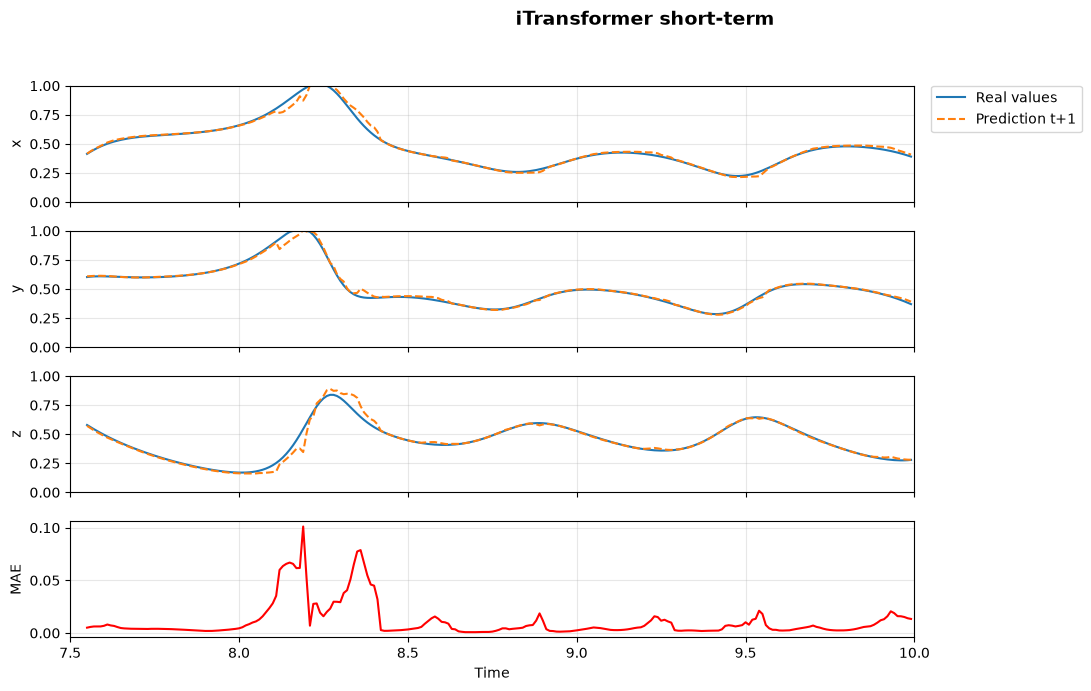

In [10]:
pred_x_short = pred_3d_short[:, :, 0]
pred_y_short = pred_3d_short[:, :, 1]
pred_z_short = pred_3d_short[:, :, 2]

plot_preds_and_error(
    pred_x_short,
    pred_y_short,
    pred_z_short,
    mean_mae_list_short,
    time_val,
    window_size,
    val_scaled,
    error="MAE",
    title="iTransformer short-term"
)

In [11]:
total, trainable = count_parameters(model_iTransformer_short)
print(f"Total parameters: {total:,} | Trainable: {trainable:,}")

Total parameters: 1,078 | Trainable: 1,078


# Long-term forecasting

In [12]:
# Create the sequences
horizon_long = 5

x_tr_long, hor_tr_long = create_sequences(train_scaled, window_size, horizon_long)
x_val_long, hor_val_long = create_sequences(val_scaled, window_size, horizon_long)

x_tr_long = torch.from_numpy(x_tr_long).double()
hor_tr_long = torch.from_numpy(hor_tr_long).double()

x_val_long = torch.from_numpy(x_val_long).double()
hor_val_long = torch.from_numpy(hor_val_long).double()

tr_dataset_long = TensorDataset(x_tr_long, hor_tr_long)
tr_loader_long = DataLoader(tr_dataset_long, batch_size=batch_size, shuffle=False)

In [13]:
reset_seeds(SEED)

# Create the model
model_iTransformer_long = iTransformer_Model(
    window_size, 
    horizon_long, 
    n_trfm_blocks,
    embding_dim,
    ff_dim,
).double()

# Define optimizer and loss function
opt_long = torch.optim.Adam(params=model_iTransformer_long.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# Save the best model
best_state_long = None
best_val_loss_long = float("inf")

history_long = {"Loss": [], "Val loss": []}

print(30 * "#")
print("Starting training")
print(30 * "#")

for epoch in range(epochs):

    #Training
    model_iTransformer_long.train()
    epoch_loss = 0
    for xb, yb in tr_loader_long:
        opt_long.zero_grad()
        pred = model_iTransformer_long(xb)
        pred = pred.reshape(pred.shape[0], -1)
        target = yb.reshape(yb.shape[0], -1)
        loss = loss_fn(pred, target)    
        loss.backward()
        opt_long.step()
        epoch_loss += loss.item()
    
    # Store average loss for this epoch
    epoch_loss /= len(tr_loader_long)
    history_long["Loss"].append(epoch_loss)

    # Evaluation
    model_iTransformer_long.eval()
    with torch.no_grad():
        val_pred = model_iTransformer_long(x_val_long)
        val_pred = val_pred.reshape(val_pred.shape[0], -1)
        val_target = hor_val_long.reshape(hor_val_long.shape[0], -1)
        val_loss = loss_fn(val_pred, val_target).item()

    # Store val loss
    history_long["Val loss"].append(val_loss)

    # Save best model
    if val_loss < best_val_loss_long:
        best_val_loss_long = val_loss
        best_state_long = {
            name: params.detach().clone()
            for name, params in model_iTransformer_long.state_dict().items()
        }

    # Print training progress every 5 epochs
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


if best_state_long is not None:
    model_iTransformer_long.load_state_dict(best_state_long)

##############################
Starting training
##############################
Epoch: 1 | Loss: 0.0054 | Validation loss: 0.0038
Epoch: 5 | Loss: 0.0049 | Validation loss: 0.0036
Epoch: 10 | Loss: 0.0043 | Validation loss: 0.0031
Epoch: 15 | Loss: 0.0034 | Validation loss: 0.0026
Epoch: 20 | Loss: 0.0024 | Validation loss: 0.0018
Epoch: 25 | Loss: 0.0018 | Validation loss: 0.0014
Epoch: 30 | Loss: 0.0015 | Validation loss: 0.0013
Epoch: 35 | Loss: 0.0014 | Validation loss: 0.0012
Epoch: 40 | Loss: 0.0014 | Validation loss: 0.0012
Epoch: 45 | Loss: 0.0013 | Validation loss: 0.0012
Epoch: 50 | Loss: 0.0013 | Validation loss: 0.0011


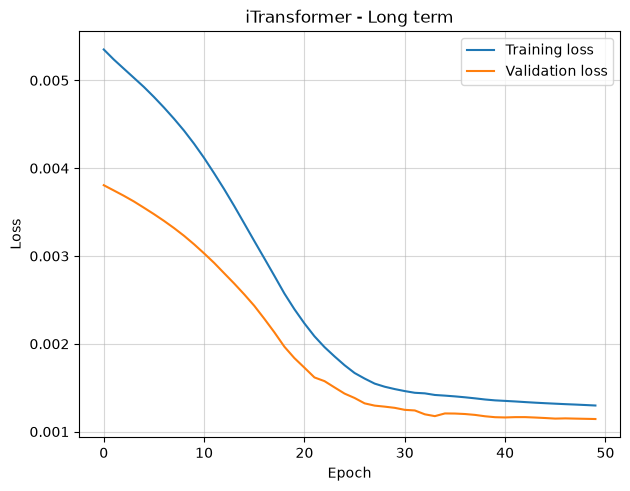

In [14]:
plot_loss(history_long, "iTransformer - Long term")

In [15]:
# Evaluation mode
model_iTransformer_long.eval()

with torch.no_grad():
    pred_long = model_iTransformer_long(x_val_long)

pred_3d_long = pred_long.reshape(pred_long.shape[0], 5, 3)
target_3d_long = hor_val_long

# =====================
# RMSE
# =====================

squared_error_long = (pred_3d_long - target_3d_long) ** 2
mean_rmse_list_long = torch.sqrt(squared_error_long.mean(dim=(1, 2)))
mean_rmse_long = torch.sqrt(squared_error_long.mean())

# =====================
# MAE
# =====================

abs_error_long = torch.abs(pred_3d_long - target_3d_long)
mean_mae_list_long = abs_error_long.mean(dim=(1, 2))
mean_mae_long = abs_error_long.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error_long = torch.abs((target_3d_long - pred_3d_long) / (target_3d_long + eps))
mean_mape_list_long = percentage_error_long.mean(dim=(1, 2))
mean_mape_long = percentage_error_long.mean()


# =====================
# MAE in t+5 (for the plot)
# =====================

h = 4  # t+5

abs_error_t5 = torch.abs(pred_3d_long[:, h, :] - target_3d_long[:, h, :])
mean_mae_t5_list = abs_error_t5.mean(dim=1)

print(f"Global RMSE: {mean_rmse_long:.4f}")
print(f"Global MAE: {mean_mae_long:.4f}")
print(f"Global MAPE: {mean_mape_long:.4f}")

Global RMSE: 0.0338
Global MAE: 0.0173
Global MAPE: 0.0362


In [16]:
# Save the results to a CSV file
save_result_csv(
    "../results/lorenz_metrics.csv",
    {
        "forecasting": "long-term",
        "model": "iTransformer",
        "MAPE": mean_mape_long,
        "MAE": mean_mae_long,
        "RMSE": mean_rmse_long,
    },
)

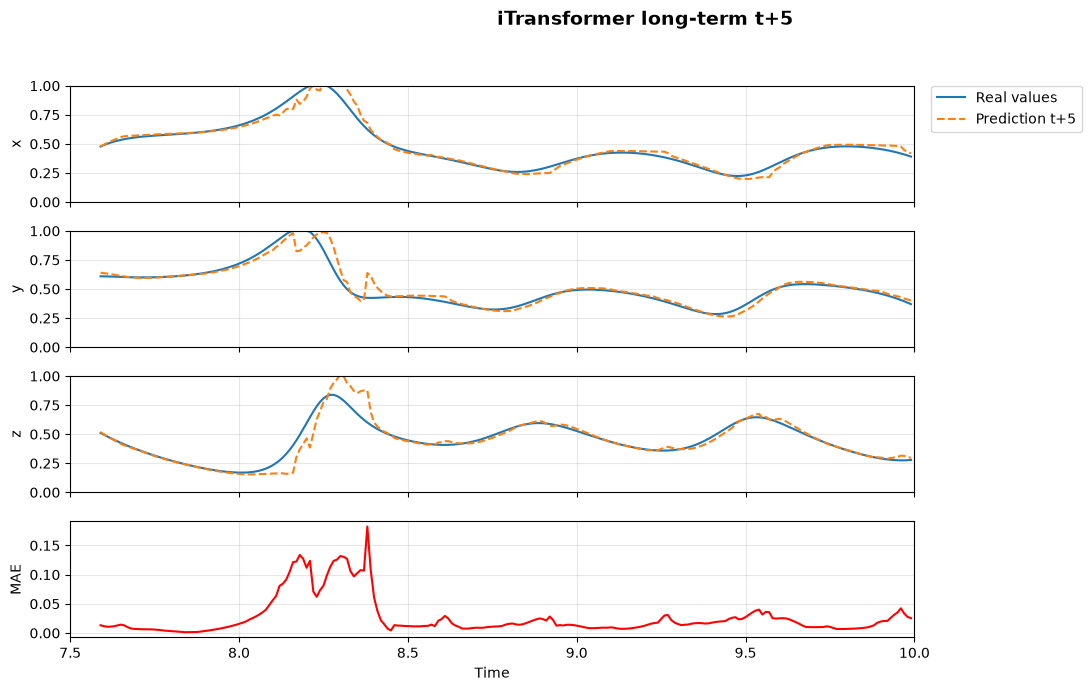

In [17]:
pred_x_long = pred_3d_long[:, :, 0]
pred_y_long = pred_3d_long[:, :, 1]
pred_z_long = pred_3d_long[:, :, 2]

plot_preds_and_error(
    pred_x_long,
    pred_y_long,
    pred_z_long,
    mean_mae_t5_list,
    time_val,
    window_size,
    val_scaled,
    error="MAE",
    horizon=horizon_long,
    horizon_step=5,
    title="iTransformer long-term t+5"
)

In [18]:
total, trainable = count_parameters(model_iTransformer_long)
print(f"Total parameters: {total:,} | Entrenables: {trainable:,}")

Total parameters: 1,118 | Entrenables: 1,118
